## A4

Bellotto Simone, Cattaneo Augusto, Hemalatha Thirumal Manasa , Leckebusch Jens, Rider Benjamin

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import bisect

### Initialization

In [2]:
# Weibull parameters
weibull_params = {
    "rotor":     {"shape": 3, "scale": 3000},
    "bearing":   {"shape": 2, "scale": 3750},
    "gearbox":   {"shape": 3, "scale": 2400},
    "generator": {"shape": 2, "scale": 3300}
}

# Costs
C_fixed = 50   # per maintenance cycle (example)
C_access = 10  # turbine-to-turbine cost

# Replacement costs
C1 = {"rotor": 112, "bearing": 60, "gearbox": 152, "generator": 100}
C2 = {"rotor": 28,  "bearing": 15, "gearbox": 38,  "generator": 25}

# Age reduction
AGE_REDUCTION = {
    "minor": 0.30,
    "major": 0.50
}

# Condition-based thresholds (for CBM)
max_age = 0.95
min_age = 0.50

# Turbines
N_turbines = 50
COMPONENTS = ["rotor", "bearing", "gearbox", "generator"]
    
# N of Monte Carlo iterations (min 500)
ITER = 1000

# Seed
np.random.seed(42)

# Number of cycles to simulate
N_cycles = 10

In [3]:
# sample failure age (similar to matlab wblrnd)
def sample_failure_age(component):
    shape = weibull_params[component]["shape"]
    scale = weibull_params[component]["scale"]
    return np.random.weibull(shape) * scale

# create windfarm
def init_windfarm():
    """
    Initialize 50 turbines × 4 components.
    """
    farm = []
    for _ in range(N_turbines):
        turbine = {}
        for comp in COMPONENTS:
            turbine[comp] = {
                "virtual_age": 0.0,
                "failure_age": sample_failure_age(comp)
            }
        farm.append(turbine)
    return farm

### Plot functions

In [4]:
def plot_amc_stabilization(all_AMC, strategy_name, title="AMC Stabilization Curve", figsize=(7,4)):
    # running avg
    running_avg_amc = np.cumsum(all_AMC) / np.arange(1, len(all_AMC) + 1)
    # total avg
    final_avg = np.mean(all_AMC)

    plt.figure(figsize=figsize)
    plt.plot(running_avg_amc, lw=1.8, label="Running average AMC")
    plt.axhline(final_avg, color='r', linestyle='--', linewidth=1.5,
                label=f"Final average AMC = {final_avg:.2f}")
    #plt.title(title)
    plt.xlabel("Monte Carlo iteration")
    plt.ylabel("Average AMC (EUR K/year)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_amc_" + strategy_name + ".png")
    plt.show()
    
def plot_coefficient_of_variation(all_AMC, strategy_name, title="Coefficient of Variation Convergence", figsize=(7,4)):
    """
    Plot the running coefficient of variation (CV) of AMC values to assess Monte Carlo convergence.
    CV = running standard deviation / running mean.
    """

    # running avg / mean
    running_mean = np.cumsum(all_AMC) / np.arange(1, len(all_AMC) + 1)

    # running var
    running_var = (np.cumsum((all_AMC - running_mean)**2)) / np.arange(1, len(all_AMC) + 1)
    running_std = np.sqrt(running_var)

    # running coefficient of variation
    running_cv = running_std / running_mean

    plt.figure(figsize=figsize)
    plt.plot(running_cv, lw=1.8, label="Running CV")
    plt.axhline(running_cv[-1], color='r', linestyle='--', linewidth=1.3,
                label=f"Final CV = {running_cv[-1]:.4f}")
    #plt.title(title)
    plt.xlabel("Monte Carlo iteration")
    plt.ylabel("Coefficient of Variation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_ac_" + strategy_name + ".png")
    plt.show()

### Analysis functions

In [5]:
def run_simple_montecarlo(strategy_function):
    #initialize
    all_AMC = []
    all_total_cost = []
    all_total_days = []
    all_fail_counts = []
    
    #montecarlo
    for _ in range(ITER):
        total_cost_10, total_days_10, AMC_10, failure_counts = strategy_function()
        all_total_cost.append(total_cost_10)
        all_total_days.append(total_days_10)
        all_AMC.append(AMC_10)
        all_fail_counts.append(failure_counts)
        
    #aggregate
    avg_AMC = float(np.mean(all_AMC))
    std_AMC = float(np.std(all_AMC, ddof=1))
    avg_total_cost = float(np.mean(all_total_cost))
    avg_total_days = float(np.mean(all_total_days))

    avg_failures = {
        comp: float(np.mean([fc[comp] for fc in all_fail_counts]))
        for comp in COMPONENTS
    }

    return all_AMC, avg_AMC, std_AMC, avg_total_cost, avg_total_days, avg_failures

### Assignment

#### Strategy 1

In [6]:
# Strategy 1 - implementation
def simulate_S1():
    
    #initialize
    farm = init_windfarm()
    total_cost = 0.0
    total_days = 0.0
    failure_counts = {c: 0 for c in COMPONENTS}
    
    # Run cycles
    for c in range(N_cycles):
        min_residual = np.inf
        failed_turbine_idx = None
        failed_component = None
        
        for ti in range(N_turbines):
            for comp in COMPONENTS:
                comp_state = farm[ti][comp]
                residual = comp_state["failure_age"] - comp_state["virtual_age"]
                if residual < min_residual:
                    min_residual = residual
                    failed_turbine_idx = ti
                    failed_component = comp
        
        #find time to next component failure
        dt = max(min_residual, 0.0)
        total_days += dt
            
        for ti in range(N_turbines):
            for comp in COMPONENTS:
                farm[ti][comp]["virtual_age"] += dt
                
        #costs # TODO: check if correct
        cycle_cost = C_fixed
        cycle_cost += C_access  # TODO: check if correct
        cycle_cost += C1[failed_component]  # corrective replacement

        total_cost += cycle_cost
        failure_counts[failed_component] += 1

        # replace component
        farm[failed_turbine_idx][failed_component]["virtual_age"] = 0.0
        farm[failed_turbine_idx][failed_component]["failure_age"] = sample_failure_age(failed_component)
        
        AMC = total_cost / total_days * 365.0
        
    return total_cost, total_days, AMC, failure_counts

  CORRECTIVE MAINTENANCE (CM) — EVENT-DRIVEN RESU   
Iterations: 1000, Cycles per iteration: 10, Turbines: 50
Average total cost over 10 cycles: 1636.35 EUR $
Average total elapsed days for 10 cycles: 875.3 days
Average AMC (per formula): 694.02 K EUR/year (std: 99.18)

Average number of failure replacements over 10 cycles (by component):
  rotor    : 1.269
  bearing  : 2.722
  gearbox  : 2.500
  generator: 3.509


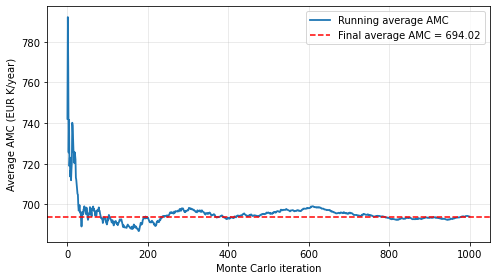

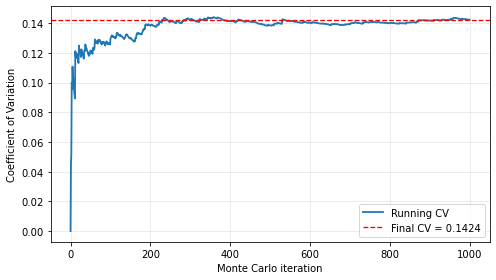

In [7]:
# Strategy 1 - execution
all_AMC, avg_AMC, std_AMC, avg_total_cost, avg_total_days, avg_failures = run_simple_montecarlo(simulate_S1)

print("============================================================")
print("  CORRECTIVE MAINTENANCE (CM) — EVENT-DRIVEN RESU   ")
print("============================================================")
print(f"Iterations: {ITER}, Cycles per iteration: {N_cycles}, Turbines: {N_turbines}")
print(f"Average total cost over 10 cycles: {avg_total_cost:.2f} EUR $")
print(f"Average total elapsed days for 10 cycles: {avg_total_days:.1f} days")
print(f"Average AMC (per formula): {avg_AMC:.2f} K EUR/year (std: {std_AMC:.2f})")
print("\nAverage number of failure replacements over 10 cycles (by component):")
for comp, val in avg_failures.items():
    print(f"  {comp:9s}: {val:.3f}")

plot_amc_stabilization(all_AMC, "s1", title="AMC Stabilization Curve", figsize=(7,4))
plot_coefficient_of_variation(all_AMC, "s1", title="Coefficient of Variation Convergence", figsize=(7,4))

#### Strategy 2

In [32]:
    import numpy as np
    import heapq
    from tqdm import tqdm
    import matplotlib.pyplot as plt

    # --- Parameters ---
    weibull_params = {
        "rotor":     {"shape": 3, "scale": 3000},
        "bearing":   {"shape": 2, "scale": 3700},
        "gearbox":   {"shape": 3, "scale": 2400},
        "generator": {"shape": 2, "scale": 3300}
    }

    C_fixed = 50
    C_access = 10
    C1 = {"rotor": 112, "bearing": 60, "gearbox": 152, "generator": 100}
    C2 = {"rotor": 28,  "bearing": 15, "gearbox": 38,  "generator": 25}
    AGE_REDUCTION = {"minor": 0.30, "major": 0.50}
    N_turbines = 50
    COMPONENTS = ["rotor", "bearing", "gearbox", "generator"]
    N_cycles = 10
    cycle_length = 365
    ITER = 2000

    # --- Helper functions ---
    def add_years(n, l):
        return [i*l for i in range(1, n+1)]

    # --- Simulation classes ---
    class Component:
        def __init__(self, name, id, age=0):
            self.name = name
            self.id = id
            self.age = age
            self.replaced = False
            self.shape = weibull_params[name]['shape']
            self.scale = weibull_params[name]['scale']
            self.failtime = np.random.weibull(self.shape) * self.scale

        def replace(self, day, failure_heap):
            self.age = 0
            self.failtime = day + np.random.weibull(self.shape) * self.scale
            self.replaced = True
            heapq.heappush(failure_heap, (self.failtime, self))

        def minor_repair(self, day):
            self.age *= (1 - AGE_REDUCTION["minor"])
            u = np.random.random()
            remaining = (self.age**self.shape - (self.scale**self.shape) * np.log(u))**(1/self.shape) - self.age
            self.failtime = day + remaining

    class Turbine:
        def __init__(self, id):
            self.id = id
            self.components = [Component(name, id) for name in COMPONENTS]

    # --- Single Monte Carlo run ---
    def run_single_mc(seed=None):
        if seed is not None:
            np.random.seed(seed)

        turbines = [Turbine(i) for i in range(N_turbines)]
        failure_heap = [(comp.failtime, comp) for turb in turbines for comp in turb.components]
        heapq.heapify(failure_heap)
        maintenance_events = add_years(N_cycles, cycle_length)

        day = 0
        total_cost = 0

        # Advance to first event
        day = min(failure_heap[0][0], maintenance_events[0])
        for turb in turbines:
            for comp in turb.components:
                comp.age += day

        while day <= (N_cycles+1) * cycle_length:
            daily_cost = 0
            maintenance = False
            serviced_turbines = set()
            next_maintenance = maintenance_events[0] if maintenance_events else float("inf")

            while day >= min(failure_heap[0][0], next_maintenance):
                if day == failure_heap[0][0]:
                    maintenance = True
                    _, comp = heapq.heappop(failure_heap)
                    serviced_turbines.add(comp.id)
                    daily_cost += C1[comp.name]
                    comp.replace(day, failure_heap)

                if day == next_maintenance:
                    maintenance = True
                    for turb in turbines:
                        serviced_turbines.add(turb.id)
                        for comp in turb.components:
                            if not comp.replaced:
                                comp.minor_repair(day)
                                daily_cost += C2[comp.name]
                            else:
                                comp.replaced = False
                    maintenance_events.pop(0)
                    next_maintenance = maintenance_events[0] if maintenance_events else float("inf")

            daily_cost += maintenance * C_fixed
            daily_cost += len(serviced_turbines) * C_access
            total_cost += daily_cost

            # Jump directly to next event
            next_failure = failure_heap[0][0] if failure_heap else float("inf")
            next_maintenance = maintenance_events[0] if maintenance_events else float("inf")
            next_day = min(next_failure, next_maintenance)
            delta = next_day - day
            if delta <= 0:
                delta = 1e-6
            day = next_day
            for turb in turbines:
                for comp in turb.components:
                    comp.age += delta

        return total_cost

    # --- Monte Carlo wrapper ---
    def monte_carlo(iterations=ITER):
        seeds = np.random.randint(0, 2**32 - 1, size=iterations)
        results = []
        for seed in tqdm(seeds, desc="MC iterations"):
            results.append(run_single_mc(seed))
        return results

    if __name__ == "__main__":
        mc_results = monte_carlo(ITER)
        
        # Convert total cost to average annual cost per iteration
        avg_annual_cost = np.array(mc_results)/(N_cycles*cycle_length)*365
    cumulative_avg_cost = [np.mean(avg_annual_cost[:i+1]) for i in range(len(avg_annual_cost))]

    plt.figure(figsize=(12,5))

    # 1. Cumulative average annual cost
    plt.subplot(1,2,1)
    plt.plot(range(1, ITER+1), cumulative_avg_cost, color='blue', lw=1)
    plt.title("Cumulative Average Annual Cost")
    plt.xlabel("Iteration")
    plt.ylabel("Average Annual Cost")
    plt.grid(True)

    # 2. Cumulative CV (already stable)
    plt.subplot(1,2,2)
    plt.plot(range(1, ITER+1), cumulative_cv, color='red', lw=1)
    plt.title("Cumulative Coefficient of Variation (CV)")
    plt.xlabel("Iteration")
    plt.ylabel("CV")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

ModuleNotFoundError: No module named 'tqdm'

#### Strategy 3

In [ ]:
    import numpy as np
    import heapq
    from tqdm import tqdm
    import matplotlib.pyplot as plt

    # --- Parameters ---
    weibull_params = {
        "rotor":     {"shape": 3, "scale": 3000},
        "bearing":   {"shape": 2, "scale": 3700},
        "gearbox":   {"shape": 3, "scale": 2400},
        "generator": {"shape": 2, "scale": 3300}
    }

    C_fixed = 50
    C_access = 10
    C1 = {"rotor": 112, "bearing": 60, "gearbox": 152, "generator": 100}
    C2 = {"rotor": 28,  "bearing": 15, "gearbox": 38,  "generator": 25}
    AGE_REDUCTION = {"minor": 0.30, "major": 0.50}
    N_turbines = 50
    COMPONENTS = ["rotor", "bearing", "gearbox", "generator"]
    N_cycles = 10
    cycle_length = 730
    ITER = 2000

    # --- Helper functions ---
    def add_years(n, l):
        return [i*l for i in range(1, n+1)]

    # --- Simulation classes ---
    class Component:
        def __init__(self, name, id, age=0):
            self.name = name
            self.id = id
            self.age = age
            self.replaced = False
            self.shape = weibull_params[name]['shape']
            self.scale = weibull_params[name]['scale']
            self.failtime = np.random.weibull(self.shape) * self.scale

        def replace(self, day, failure_heap):
            self.age = 0
            self.failtime = day + np.random.weibull(self.shape) * self.scale
            self.replaced = True
            heapq.heappush(failure_heap, (self.failtime, self))

        def minor_repair(self, day):
            self.age *= (1 - AGE_REDUCTION["minor"])
            u = np.random.random()
            remaining = (self.age**self.shape - (self.scale**self.shape) * np.log(u))**(1/self.shape) - self.age
            self.failtime = day + remaining

    class Turbine:
        def __init__(self, id):
            self.id = id
            self.components = [Component(name, id) for name in COMPONENTS]

    # --- Single Monte Carlo run ---
    def run_single_mc(seed=None):
        if seed is not None:
            np.random.seed(seed)

        turbines = [Turbine(i) for i in range(N_turbines)]
        failure_heap = [(comp.failtime, comp) for turb in turbines for comp in turb.components]
        heapq.heapify(failure_heap)
        maintenance_events = add_years(N_cycles, cycle_length)

        day = 0
        total_cost = 0

        # Advance to first event
        day = min(failure_heap[0][0], maintenance_events[0])
        for turb in turbines:
            for comp in turb.components:
                comp.age += day

        while day <= (N_cycles+1) * cycle_length:
            daily_cost = 0
            maintenance = False
            serviced_turbines = set()
            next_maintenance = maintenance_events[0] if maintenance_events else float("inf")

            while day >= min(failure_heap[0][0], next_maintenance):
                if day == failure_heap[0][0]:
                    maintenance = True
                    _, comp = heapq.heappop(failure_heap)
                    serviced_turbines.add(comp.id)
                    daily_cost += C1[comp.name]
                    comp.replace(day, failure_heap)

                if day == next_maintenance:
                    maintenance = True
                    for turb in turbines:
                        serviced_turbines.add(turb.id)
                        for comp in turb.components:
                            if not comp.replaced:
                                comp.minor_repair(day)
                                daily_cost += C2[comp.name]
                            else:
                                comp.replaced = False
                    maintenance_events.pop(0)
                    next_maintenance = maintenance_events[0] if maintenance_events else float("inf")

            daily_cost += maintenance * C_fixed
            daily_cost += len(serviced_turbines) * C_access
            total_cost += daily_cost

            # Jump directly to next event
            next_failure = failure_heap[0][0] if failure_heap else float("inf")
            next_maintenance = maintenance_events[0] if maintenance_events else float("inf")
            next_day = min(next_failure, next_maintenance)
            delta = next_day - day
            if delta <= 0:
                delta = 1e-6
            day = next_day
            for turb in turbines:
                for comp in turb.components:
                    comp.age += delta

        return total_cost

    # --- Monte Carlo wrapper ---
    def monte_carlo(iterations=ITER):
        seeds = np.random.randint(0, 2**32 - 1, size=iterations)
        results = []
        for seed in tqdm(seeds, desc="MC iterations"):
            results.append(run_single_mc(seed))
        return results

    if __name__ == "__main__":
        mc_results = monte_carlo(ITER)
        
        # Convert total cost to average annual cost per iteration
        avg_annual_cost = np.array(mc_results)/(N_cycles*cycle_length)*365
    cumulative_avg_cost = [np.mean(avg_annual_cost[:i+1]) for i in range(len(avg_annual_cost))]

    plt.figure(figsize=(12,5))

    # 1. Cumulative average annual cost
    plt.subplot(1,2,1)
    plt.plot(range(1, ITER+1), cumulative_avg_cost, color='blue', lw=1)
    plt.title("Cumulative Average Annual Cost")
    plt.xlabel("Iteration")
    plt.ylabel("Average Annual Cost")
    plt.grid(True)

    # 2. Cumulative CV (already stable)
    plt.subplot(1,2,2)
    plt.plot(range(1, ITER+1), cumulative_cv, color='red', lw=1)
    plt.title("Cumulative Coefficient of Variation (CV)")
    plt.xlabel("Iteration")
    plt.ylabel("CV")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

ModuleNotFoundError: No module named 'tqdm'

#### Strategy 4

In [8]:
# Strategy 4 Condition-Based Maintenance (CBM)

# This strategy initiates a maintenance cycle only when a component fails.
# During that maintenance cycle, other components are inspected and
# preventive actions are taken depending on their virtual age relative
# to their failure age.
#
# Age thresholds used:
# >95% of failure age  -> Preventive replacement
# 70–95%               -> Major repair (50% age reduction)
# 50–70%               -> Minor repair (30% age reduction)
# ≤50%                 -> No repair
# -------------------------------------------------------------

def simulate_S4():

    # Initialize the wind farm state
    farm = init_windfarm()

    total_cost = 0.0
    total_days = 0.0

    # Counters for different maintenance actions
    failure_counts = {c: 0 for c in COMPONENTS}
    preventive_counts = {c: 0 for c in COMPONENTS}
    major_counts = {c: 0 for c in COMPONENTS}
    minor_counts = {c: 0 for c in COMPONENTS}

    # Run maintenance cycles
    for cycle in range(N_cycles):

        # -----------------------------------------------------
        # STEP 1: Identify the next failure event in the system
        # -----------------------------------------------------
        min_residual = np.inf
        failed_turbine_idx = None
        failed_component = None

        for ti in range(N_turbines):
            for comp in COMPONENTS:

                comp_state = farm[ti][comp]

                # Remaining life before failure
                residual = comp_state["failure_age"] - comp_state["virtual_age"]

                if residual < min_residual:
                    min_residual = residual
                    failed_turbine_idx = ti
                    failed_component = comp

        # Advance system time to the failure event
        total_days += min_residual

        # Update virtual ages of all components
        for ti in range(N_turbines):
            for comp in COMPONENTS:
                farm[ti][comp]["virtual_age"] += min_residual

        # -----------------------------------------------------
        # STEP 2: Corrective replacement of the failed component
        # -----------------------------------------------------
        failure_counts[failed_component] += 1

        total_cost += C_fixed + C_access + C1[failed_component]

        # Replace failed component with new one
        farm[failed_turbine_idx][failed_component]["virtual_age"] = 0
        farm[failed_turbine_idx][failed_component]["failure_age"] = sample_failure_age(failed_component)

        # -----------------------------------------------------
        # STEP 3: Condition-based preventive maintenance
        # -----------------------------------------------------
        # Check all other components in the same turbine
        for comp in COMPONENTS:

            if comp == failed_component:
                continue

            comp_state = farm[failed_turbine_idx][comp]

            age_ratio = comp_state["virtual_age"] / comp_state["failure_age"]

            # Preventive replacement
            if age_ratio > 0.95:

                preventive_counts[comp] += 1
                total_cost += C2[comp]

                comp_state["virtual_age"] = 0
                comp_state["failure_age"] = sample_failure_age(comp)

            # Major repair (50% age reduction)
            elif age_ratio > 0.70:

                major_counts[comp] += 1

                xd = 0.50
                repair_cost = C2[comp] * (xd / 2)

                total_cost += repair_cost
                comp_state["virtual_age"] *= (1 - xd)

            # Minor repair (30% age reduction)
            elif age_ratio > 0.50:

                minor_counts[comp] += 1

                xd = 0.30
                repair_cost = C2[comp] * (xd / 2)

                total_cost += repair_cost
                comp_state["virtual_age"] *= (1 - xd)

            # ≤50% → no maintenance action
            else:
                pass

    # ---------------------------------------------------------
    # STEP 4: Calculate Annual Maintenance Cost (AMC)
    # ---------------------------------------------------------
    AMC = (total_cost / total_days) * 365

    return total_cost, total_days, AMC, failure_counts

  CONDITION BASED MAINTENANCE (CBM)
Iterations: 1000, Cycles per iteration: 10, Turbines: 50
Average total cost over 10 cycles: 1659.23
Average AMC: 685.69
Std AMC: 96.85
Average failure counts: {'rotor': 1.348, 'bearing': 2.707, 'gearbox': 2.536, 'generator': 3.409}
No. of iterations = 1000
Coefficient of Variation: 0.1412391922678427


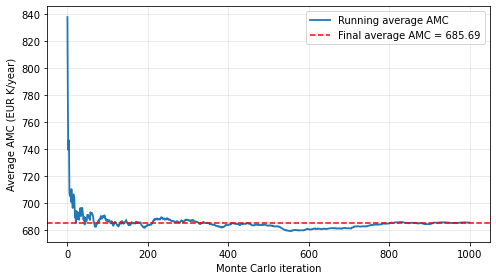

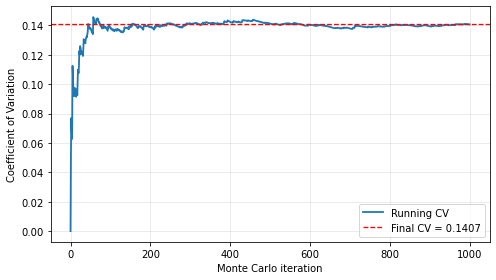

In [14]:
# Strategy 4 - execution
all_AMC, avg_AMC, std_AMC, avg_total_cost, avg_total_days, avg_failures = run_simple_montecarlo(simulate_S4)

print("============================================================")
print("  CONDITION BASED MAINTENANCE (CBM)")
print("============================================================")
print(f"Iterations: {ITER}, Cycles per iteration: {N_cycles}, Turbines: {N_turbines}")
print(f"Average total cost over 10 cycles: {avg_total_cost:.2f}")
print(f"Average AMC: {avg_AMC:.2f}")
print(f"Std AMC: {std_AMC:.2f}")
print("Average failure counts:", avg_failures)

print("No. of iterations =", len(all_AMC))

cv_amc = std_AMC / avg_AMC
print("Coefficient of Variation:", cv_amc)

plot_amc_stabilization(all_AMC, "CBM")
plot_coefficient_of_variation(all_AMC, "CBM")

In [10]:
# ---------------------------------------------------------
# Run one simulation to get maintenance counts
# ---------------------------------------------------------

total_cost, total_days, AMC, failure_counts = simulate_S4()

In [11]:
# ---------------------------------------------------------
# Print maintenance action counts
# ---------------------------------------------------------

total_failures = sum(failure_counts.values())
total_preventive = sum(preventive_counts.values())
total_major = sum(major_counts.values())
total_minor = sum(minor_counts.values())

print("================================================")
print("Maintenance Action Counts (Strategy 4 - CBM)")
print("================================================")

print(f"Failures: {total_failures}")
print(f"Preventive replacements: {total_preventive}")
print(f"Major repairs: {total_major}")
print(f"Minor repairs: {total_minor}")

NameError: name 'preventive_counts' is not defined

In [12]:
import matplotlib.pyplot as plt

actions = ["Failures", "Preventive", "Major Repair", "Minor Repair"]
values = [total_failures, total_preventive, total_major, total_minor]

plt.figure(figsize=(8,5))
plt.bar(actions, values)

plt.title("Maintenance Action Distribution - Strategy 4 (CBM)")
plt.xlabel("Maintenance Type")
plt.ylabel("Number of Actions")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

NameError: name 'total_preventive' is not defined

### Analysis